In [262]:
from heapq import merge
from shlex import join
from statistics import mean

import pandas as pd
import numpy as np

In [263]:
result = pd.read_csv('data/results.csv', na_values=['\\N'])
race = pd.read_csv('data/races.csv')

print(result.head())
print(race.head())

   resultId  raceId  driverId  constructorId  number  grid  position  \
0         1      18         1              1    22.0     1       1.0   
1         2      18         2              2     3.0     5       2.0   
2         3      18         3              3     7.0     7       3.0   
3         4      18         4              4     5.0    11       4.0   
4         5      18         5              1    23.0     3       5.0   

  positionText  positionOrder  points  laps         time  milliseconds  \
0            1              1    10.0    58  1:34:50.616     5690616.0   
1            2              2     8.0    58       +5.478     5696094.0   
2            3              3     6.0    58       +8.163     5698779.0   
3            4              4     5.0    58      +17.181     5707797.0   
4            5              5     4.0    58      +18.014     5708630.0   

   fastestLap  rank fastestLapTime  fastestLapSpeed  statusId  
0        39.0   2.0       1:27.452          218.300       

In [264]:
df = pd.merge(
    result,
    race,
    on="raceId",
    how="inner"
)
print(result.shape)

print(df.shape)
print(df.columns.to_list())

(26759, 18)
(26759, 35)
['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'positionOrder', 'points', 'laps', 'time_x', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed', 'statusId', 'year', 'round', 'circuitId', 'name', 'date', 'time_y', 'url', 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time', 'sprint_date', 'sprint_time']


In [265]:
cols = ['resultId', 'raceId', 'driverId', 'constructorId', 'grid', 'position', 'points', 'laps', 'fastestLap', 'positionOrder', 'date', 'circuitId', 'year', 'round' ]
df = df[cols]

df['top3'] = (df['positionOrder'] <= 3).astype(int)

df['top3'].value_counts()

top3
0    23362
1     3397
Name: count, dtype: int64

In [266]:
print(df.isnull().sum())
print(df.dtypes)

resultId             0
raceId               0
driverId             0
constructorId        0
grid                 0
position         10953
points               0
laps                 0
fastestLap       18507
positionOrder        0
date                 0
circuitId            0
year                 0
round                0
top3                 0
dtype: int64
resultId           int64
raceId             int64
driverId           int64
constructorId      int64
grid               int64
position         float64
points           float64
laps               int64
fastestLap       float64
positionOrder      int64
date                 str
circuitId          int64
year               int64
round              int64
top3               int64
dtype: object


In [267]:
print(df['position'].value_counts().head(10))


df = df.dropna(subset=['position'])
print(df.shape)
print(df.isnull().sum())
print(df['position'].dtype)

position
3.0     1135
4.0     1135
2.0     1133
5.0     1131
1.0     1128
6.0     1124
7.0     1104
8.0     1076
9.0     1038
10.0     978
Name: count, dtype: int64
(15806, 15)
resultId            0
raceId              0
driverId            0
constructorId       0
grid                0
position            0
points              0
laps                0
fastestLap       8785
positionOrder       0
date                0
circuitId           0
year                0
round               0
top3                0
dtype: int64
float64


In [268]:
df = df.drop('fastestLap', axis=1)
print(df.shape)
print(df.columns.to_list())

(15806, 14)
['resultId', 'raceId', 'driverId', 'constructorId', 'grid', 'position', 'points', 'laps', 'positionOrder', 'date', 'circuitId', 'year', 'round', 'top3']


In [269]:
print(df[df['grid'] == 0][['grid', 'positionOrder', 'top3']].head(10))
print(df[df['grid'] == 0]['top3'].value_counts())
print(df['grid'].describe())

       grid  positionOrder  top3
22641     0             10     0
23107     0             20     0
24246     0             10     0
24266     0             10     0
24272     0             16     0
24289     0             13     0
24336     0             17     0
24377     0             18     0
24456     0             17     0
24474     0             15     0
top3
0    60
Name: count, dtype: int64
count    15806.000000
mean        10.976528
std          6.703464
min          0.000000
25%          5.000000
50%         10.000000
75%         16.000000
max         33.000000
Name: grid, dtype: float64


In [270]:
mediana_grid = df['grid'].median()
df['grid'] = df['grid'].replace(0, mediana_grid)

print(df[df['grid'] == 0].shape)  # deve dar (0, ...)

(0, 14)


In [271]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by='date').reset_index(drop=True)
print(df['date'].dtype)
print(df[['date', 'driverId']].head(10))

datetime64[us]
        date  driverId
0 1950-05-13       741
1 1950-05-13       787
2 1950-05-13       619
3 1950-05-13       627
4 1950-05-13       704
5 1950-05-13       686
6 1950-05-13       786
7 1950-05-13       642
8 1950-05-13       660
9 1950-05-13       788


In [272]:
print(df.columns.tolist())
print(df.shape)
print(df[['date', 'driverId', 'year', 'round']].head(5))

['resultId', 'raceId', 'driverId', 'constructorId', 'grid', 'position', 'points', 'laps', 'positionOrder', 'date', 'circuitId', 'year', 'round', 'top3']
(15806, 14)
        date  driverId  year  round
0 1950-05-13       741  1950      1
1 1950-05-13       787  1950      1
2 1950-05-13       619  1950      1
3 1950-05-13       627  1950      1
4 1950-05-13       704  1950      1


In [273]:
df['avg_position_last5'] = df.groupby('driverId')['positionOrder'] \
    .transform(lambda x: x.shift(1).rolling(5).mean())
print(df[['driverId', 'date', 'positionOrder', 'avg_position_last5']].head(15))



    driverId       date  positionOrder  avg_position_last5
0        741 1950-05-13              8                 NaN
1        787 1950-05-13              7                 NaN
2        619 1950-05-13              6                 NaN
3        627 1950-05-13              5                 NaN
4        704 1950-05-13              4                 NaN
5        686 1950-05-13              3                 NaN
6        786 1950-05-13              2                 NaN
7        642 1950-05-13              1                 NaN
8        660 1950-05-13             11                 NaN
9        788 1950-05-13             10                 NaN
10       778 1950-05-13             10                 NaN
11       784 1950-05-13              9                 NaN
12       579 1950-05-21              1                 NaN
13       647 1950-05-21              2                 NaN
14       589 1950-05-21              3                 NaN


In [274]:
piloto_exemplo = df[df['driverId'] == 1][['date', 'positionOrder', 'avg_position_last5']].head(10)
print(piloto_exemplo)

           date  positionOrder  avg_position_last5
9575 2007-03-18              3                 NaN
9588 2007-04-08              2                 NaN
9610 2007-04-15              2                 NaN
9625 2007-05-13              2                 NaN
9636 2007-05-27              2                 NaN
9656 2007-06-10              1                 2.2
9670 2007-06-17              1                 1.8
9688 2007-07-01              3                 1.6
9697 2007-07-08              3                 1.8
9711 2007-07-22              9                 2.0


In [275]:
df = df.dropna(subset='avg_position_last5')
print(df.shape)
piloto_exemplo = df[df['driverId'] == 1][['date', 'positionOrder', 'avg_position_last5']].head(10)
print(piloto_exemplo)

(13478, 15)
           date  positionOrder  avg_position_last5
9656 2007-06-10              1                 2.2
9670 2007-06-17              1                 1.8
9688 2007-07-01              3                 1.6
9697 2007-07-08              3                 1.8
9711 2007-07-22              9                 2.0
9735 2007-08-05              1                 3.4
9754 2007-08-26              5                 3.4
9772 2007-09-09              2                 4.2
9792 2007-09-16              4                 4.0
9811 2007-09-30              1                 4.2


In [276]:
df['nTop3Last5Race'] = df.groupby('driverId')['top3'] \
    .transform(lambda x: x.shift(1).rolling(5).sum())
df = df.dropna(subset='nTop3Last5Race')
print(df[df['driverId'] == 1][['date', 'top3', 'nTop3Last5Race']].head(10))

           date  top3  nTop3Last5Race
9735 2007-08-05     1             4.0
9754 2007-08-26     0             4.0
9772 2007-09-09     1             3.0
9792 2007-09-16     0             3.0
9811 2007-09-30     1             2.0
9835 2007-10-21     0             3.0
9843 2008-03-16     1             2.0
9866 2008-03-23     0             3.0
9876 2008-04-06     0             2.0
9897 2008-04-27     1             2.0


In [277]:
team_points = df.groupby(['raceId', 'constructorId'])['points'] \
    .sum().reset_index()
team_points.columns = ['raceId', 'constructorId', 'team_points_race']

team_points = team_points.sort_values(by='raceId')
team_points['team_avg_points_last5'] = team_points.groupby('constructorId')['team_points_race'] \
    .transform(lambda x: x.shift(1).rolling(5).mean())

print(team_points.columns.tolist())

['raceId', 'constructorId', 'team_points_race', 'team_avg_points_last5']


In [278]:
df = pd.merge(
    df,          # ← df principal (não perdes linhas daqui)
    team_points[['raceId', 'constructorId', 'team_avg_points_last5']],
    on=['raceId', 'constructorId'],
    how='left'
)

print(df.shape)  # deve ter o mesmo nº de linhas que antes!
print(df[df['team_avg_points_last5'].isna()].shape)

(12042, 17)
(585, 17)


In [279]:
df['driver_experience'] = df.groupby('driverId').cumcount()
print(df[df['driverId'] == 1][['date', 'driver_experience']].head(8))
print(df['driver_experience'].describe())

           date  driver_experience
6565 2007-08-05                  0
6579 2007-08-26                  1
6593 2007-09-09                  2
6611 2007-09-16                  3
6628 2007-09-30                  4
6649 2007-10-21                  5
6657 2008-03-16                  6
6676 2008-03-23                  7
count    12042.000000
mean        59.557632
std         60.551602
min          0.000000
25%         15.000000
50%         39.000000
75%         84.000000
max        323.000000
Name: driver_experience, dtype: float64


In [280]:
print(df[['position', 'positionOrder', 'laps']].tail(20))

       position  positionOrder  laps
12022       3.0              3    57
12023       2.0              2    57
12024       1.0              1    57
12025       7.0              7    57
12026      14.0             14    57
12027      13.0             13    57
12028      12.0             12    57
12029      11.0             11    57
12030      10.0             10    58
12031       9.0              9    58
12032       5.0              5    58
12033       7.0              7    58
12034       6.0              6    58
12035       4.0              4    58
12036       3.0              3    58
12037       2.0              2    58
12038       1.0              1    58
12039      16.0             16    57
12040       8.0              8    58
12041      17.0             17    55


In [281]:
features = ['grid', 'avg_position_last5', 'nTop3Last5Race',
            'team_avg_points_last5', 'driver_experience']
X = df[features]
y = df['top3']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape, X_test.shape)

(9633, 5) (2409, 5)


In [282]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')  # 'median' ou 'mean' ou 'constant'
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)
model = LogisticRegression(random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))




              precision    recall  f1-score   support

           0       0.95      0.80      0.87      1802
           1       0.59      0.87      0.71       607

    accuracy                           0.82      2409
   macro avg       0.77      0.83      0.79      2409
weighted avg       0.86      0.82      0.83      2409



In [283]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89      1802
           1       0.70      0.63      0.66       607

    accuracy                           0.84      2409
   macro avg       0.79      0.77      0.78      2409
weighted avg       0.83      0.84      0.84      2409



In [284]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      1802
           1       0.71      0.66      0.69       607

    accuracy                           0.85      2409
   macro avg       0.80      0.79      0.79      2409
weighted avg       0.84      0.85      0.84      2409



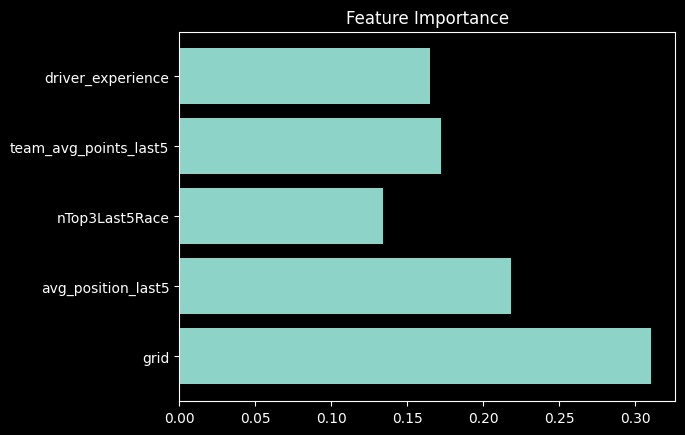

In [285]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
feat_names = features
plt.barh(feat_names, importances)
plt.title('Feature Importance')
plt.show()